In [8]:
import pandas as pd
import numpy as np

In [9]:
raw = pd.read_csv('https://hilpisch.com/pyalgo_eikon_eod_data.csv',
                            index_col=0, parse_dates=True).dropna()

In [10]:
data = pd.DataFrame(raw['XAU='])

In [11]:
data.rename(columns={'XAU=': 'price'}, inplace=True) 

In [12]:
data['returns'] = np.log(data['price'] / data['price'].shift(1))

In [13]:
data['position'] = np.sign(data['returns'])

In [14]:
data['strategy'] = data['position'].shift(1) * data['returns']

<Axes: xlabel='Date'>

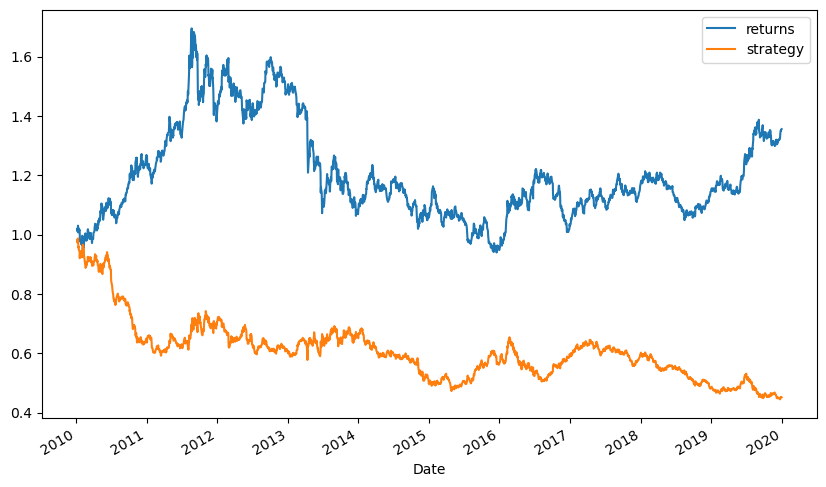

In [15]:
data[['returns', 'strategy']].dropna().cumsum(

).apply(np.exp).plot(figsize=(10,6))

In [22]:
data['position'] = np.sign(data['returns'].rolling(3).mean())

In [23]:
data['strategy'] = data['position'].shift(1) * data['returns']

<Axes: xlabel='Date'>

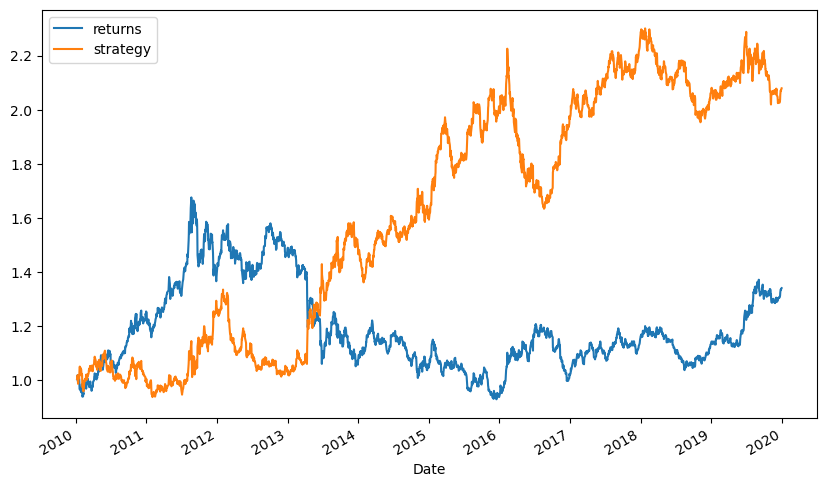

In [24]:
data[['returns', 'strategy']].dropna().cumsum(
).apply(np.exp).plot(figsize=(10,6))

In [25]:
data['position'] = np.sign(data['returns'].rolling(2).mean())

In [26]:
data['strategy'] = data['position'].shift(1) * data['returns']

<Axes: xlabel='Date'>

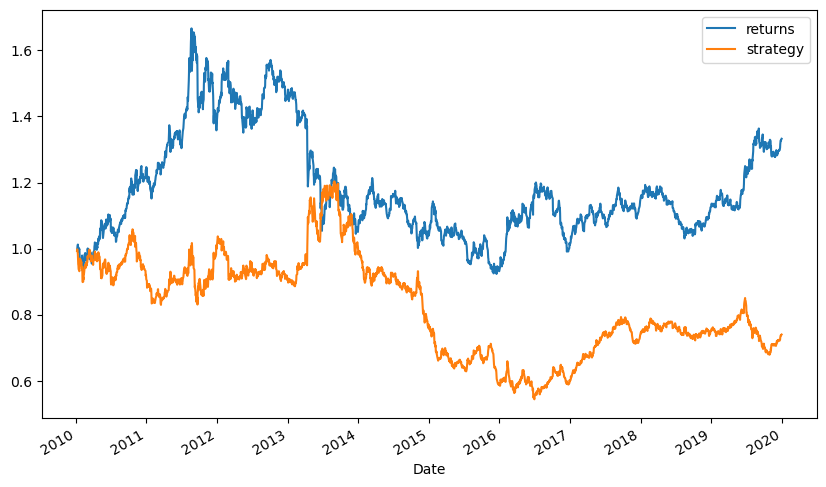

In [27]:
data[['returns', 'strategy']].dropna().cumsum(
).apply(np.exp).plot(figsize=(10,6))